In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import product
import random
from tqdm import tqdm
import ast
from collections import OrderedDict
from pprint import pprint

def gen_directed_graphs(n=4, m=15):
    graphs = defaultdict(list)

    for i in range(n):
        G = nx.DiGraph()  # Create a directed graph
        nodes = [j for j in range(m)]  # Create a list of nodes
        # edges = list(zip(nodes[:-1], nodes[1:]))  # Create edges between consecutive nodes

        # make sure the edge is not a loop
        # edges = [(random.choice(nodes), random.choice(nodes)) for _ in range(m)]
        used_nodes = set()
        edges = []

        while len(edges) < m:
            pos1 = random.choice(nodes)
            pos2 = random.choice(nodes)

            if (pos1, pos2) not in edges and (pos2, pos1) not in edges and pos1 != pos2:
                edges.append((pos1, pos2))
                used_nodes.add(pos1)
                used_nodes.add(pos2)

                # If we're about to finish but haven't used all nodes,
                # reject this attempt and start over
                remaining_edges = m - len(edges)
                unused_nodes = set(nodes) - used_nodes
                if remaining_edges < len(unused_nodes):
                    edges = []
                    used_nodes = set()

        # filter out edges from edges that loop
        # edges = [(u, v) for u, v in edges if u != v]
        
        # Assign random directions to edges
        random_edges = set()

        for u, v in edges:
            if random.choice([True, False]):  # Randomly decide the direction
                random_edges.add((u, v))
            else:
                random_edges.add((v, u))

        random_edges = list(random_edges)
        
        
        G.add_edges_from(random_edges)  # Add edges with random directions

        if(nx.number_weakly_connected_components(G) > 1):
            
            main_component = max(nx.weakly_connected_components(G), key=len)  # Find the largest connected component
            print(nx.number_weakly_connected_components(G))
            print(f"Main connected component: {main_component}")
            # iterate through weakly connected components aside the main one
            for component in [c for c in nx.weakly_connected_components(G) if c != main_component]:
                num_of_connections = random.randint(1, len(component))
                print(f"Weakly connected component: {component}")
                # choose random nodes from the component based on num_of_connections
                random_nodes = random.sample(sorted(component), num_of_connections)
                # connect each node from random_nodes to random node from the main component
                for node in random_nodes:
                    G.add_edge(node, random.choice(list(main_component)))

        else:
            print("one component")

        graphs[i] = G.to_undirected()
        
    return graphs

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:

                number_of_groups = random.randint(1,3)
                group_conditions = []

                for x in range(number_of_groups):

                    num_deps = random.randint(1, 3)
                    
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []

                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})

                    group_conditions.append(enabling_conditions)
                
                G.edges[edge]['enabling'] = group_conditions if len(group_conditions) > 0 else None
    
    return chains

def get_sample(vector, graphs):
    num_states = len(graphs[0].nodes())
    vec = list(vector)  # [1,2,3,4]
    for i in range(num_states):
        if vec[0] != i:
            yield vec, i

def filter_unique_paths(paths_lst):
    if not paths_lst:
        return []
    
    # Keep track of which paths should be excluded
    paths_to_exclude = set()
    
    # For each path, check if it contains any shorter path as a subsequence
    for path in paths_lst:
        for other_path in paths_lst:
            # Skip if same path or if other_path is not shorter
            if path == other_path or len(other_path) >= len(path):
                continue
                
            # Check if other_path is a subsequence of path
            j, k = 0, 0  # j for other_path, k for path
            while j < len(other_path) and k < len(path):
                if other_path[j] == path[k]:
                    j += 1
                k += 1
                
            # If other_path is a subsequence of path, exclude path
            if j == len(other_path):
                paths_to_exclude.add(tuple(path))
                break
    
    # Return all paths except those that contain shorter paths as subsequences
    return [path for path in paths_lst if tuple(path) not in paths_to_exclude]

# def get_vectors(chains):
#     states_per_chain = []

#     for chain_id in range(len(chains)):
#         states_per_chain.append(list(chains[chain_id].nodes()))
#         iters += 1
#         print(iters)
#         if iters >= MAX_SAMPLES:
#             break
    
#     return list(product(*states_per_chain))

def get_vectors(chains, max_combinations=300_000, max_states_per_chain=20):
    """
    Get all possible state combinations across automata with safety limits.
    
    Args:
        chains: Dictionary of networkx graphs representing automata
        max_combinations: Maximum number of combinations to generate (default: 100,000)
        max_states_per_chain: Maximum states per automaton to consider (default: 20)
    
    Returns:
        List of tuples representing all possible state combinations
    """
    states_per_chain = []
    
    # Safety check: ensure chains is not empty
    if not chains:
        print("Warning: No chains provided")
        return []
    
    # Calculate potential size before processing
    total_combinations = 1
    
    for chain_id in range(len(chains)):
        if chain_id not in chains:
            print(f"Warning: Missing chain_id {chain_id}")
            continue
            
        graph = chains[chain_id]
        
        # Safety check: ensure graph has nodes
        nodes = list(graph.nodes())
        if not nodes:
            print(f"Warning: Chain {chain_id} has no nodes")
            return []
        
        # Limit states per chain to prevent explosion
        if len(nodes) > max_states_per_chain:
            print(f"Warning: Chain {chain_id} has {len(nodes)} states, limiting to {max_states_per_chain}")
            nodes = nodes[:max_states_per_chain]
        
        states_per_chain.append(nodes)
        total_combinations *= len(nodes)
        
        # Early exit if combinations would exceed limit
        if total_combinations > max_combinations:
            print(f"Error: Potential combinations ({total_combinations:,}) exceed limit ({max_combinations:,})")
            print(f"Consider reducing number of automata or states per automaton")
            print(f"Current automata states: {[len(states) for states in states_per_chain]}")
            
            # Try to salvage by reducing states in problematic chains
            while total_combinations > max_combinations and states_per_chain:
                # Find the chain with most states and reduce it
                max_idx = max(range(len(states_per_chain)), key=lambda i: len(states_per_chain[i]))
                if len(states_per_chain[max_idx]) <= 2:
                    # Can't reduce further, return empty
                    print("Cannot reduce further while maintaining at least 2 states per chain")
                    return []
                
                # Remove one state from the largest chain
                states_per_chain[max_idx] = states_per_chain[max_idx][:-1]
                
                # Recalculate total
                total_combinations = 1
                for states in states_per_chain:
                    total_combinations *= len(states)
                
                print(f"Reduced to {total_combinations:,} combinations")
            
            if total_combinations > max_combinations:
                print("Still too many combinations after reduction")
                return []
    
    print(f"Generating {total_combinations:,} state combinations...")
    
    try:
        # Use itertools.product with the unpacked states
        from itertools import product
        result = list(product(*states_per_chain))
        
        # Double-check the result size
        if len(result) > max_combinations:
            print(f"Warning: Generated {len(result):,} combinations, truncating to {max_combinations:,}")
            result = result[:max_combinations]
        
        print(f"Successfully generated {len(result):,} combinations")
        return result
        
    except MemoryError:
        print("Memory error encountered while generating combinations")
        return []
    except Exception as e:
        print(f"Error generating combinations: {e}")
        return []

def solve(curr_states, target_node, graphs, orig_state_len, log=[], depth=0):
    '''
    Solves the problem of reaching target node from current state in graphs by returning the resulting state and log of steps.
    Parameters:
        curr_states: list of current states of automatas; LIST of INTEGERS
        target_node: target node; INTEGER
        graphs: list of graphs; LIST of networkx graphs
        log: list of log messages; LIST of STRINGS
        depth: depth of recursion; INTEGER
    Returns:
        out: states of automatas after solving or None if no solution; LIST of INTEGERS/None
            out: log: list of log messages; LIST of STRINGS
    '''
    curr_automata_id = orig_state_len - len(curr_states)
    indent = '-'*depth*2
    # log.append(f"{'-'*50}")
    curr_states_cpy = curr_states.copy()
    log.append(f"{indent}S {curr_states_cpy} TN {target_node}")
    # get all paths from current state to target node
    paths_lst = list(nx.all_simple_paths(graphs[0], curr_states_cpy[0], target_node))
    # check if a shorter path isn't already in a different longer path
    paths_lst = filter_unique_paths(paths_lst)
    log.append(f"{indent}PL {paths_lst}")
    
    # check if there is a path
    if len(paths_lst) == 0:
        log.append(f"{indent}NOPATH {curr_states} TN {target_node}")
        return None, log
    
    # check if current node equals target node
    if curr_states_cpy[0] == target_node:
        log.append(f"{indent}REND {curr_states_cpy}")
        return curr_states_cpy, log
    
    # path or paths exist and we are not in target node
    for path in paths_lst:
        log.append(f"{indent}PATH {curr_automata_id}: {path}")
        # projdu hrany po ceste (3-4), ziskam enabling
        curr_states_cpy = curr_states.copy()
        rules = graphs[0].get_edge_data(curr_states_cpy[0], path[1])
        # pokud neexistuje enabling, projdu edge
        log.append(f"{indent}RLS {rules}")
        if rules == {}:
            log.append(f"{indent}NOR {curr_states_cpy} TN {target_node}")
            # pokud má path jeden node, tak je to konec
            # log.append(f"{indent}{orig_state_len - len(curr_states_cpy)} {'U' if path[1] > curr_states_cpy[0] else 'D'}")

            log.append(f"{indent}{curr_automata_id}: {curr_states_cpy[0]} -> {path[1]}")
            curr_states_cpy[0] = path[1]
            log.append(f"{indent}NORCH {curr_states_cpy}")

            return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)

        # pokud existuje enabling, tak treba automat 1 ma byt ve stavu 2 a automat 2 ma byt ve stavu 3
        # prvni vyresime prvni pravidlo a pak druhe
        else:
            for rule_set in rules['enabling']:
                log.append(f"{indent}RS {rule_set}")

                curr_states_cpy = curr_states.copy()
                found = True

                for rule in sorted(rule_set, key=lambda x: x['automata_id']): # sorted znamena setrizene od nejvice zavisleho po nejmene
                    log.append(f"{indent}RULE {rule}")
                    idx = max(rule['automata_id'] - (orig_state_len - len(curr_states_cpy)), 0)
                    current_sub_state, log = solve(curr_states_cpy[idx:], rule['node_id'], graphs[idx:], orig_state_len, log, depth+1)

                    log.append(f"{indent}RCH {current_sub_state}")
                    if current_sub_state == None:
                        found = False
                        break
                    log.append(f"{indent}SUB {curr_states_cpy}")
                    curr_states_cpy[idx:] = current_sub_state
                    log.append(f"{indent}SUBCH {curr_states_cpy}")

                if found:
                    log.append(f"{indent}SUBF {curr_states_cpy}")
                    # log.append(f"{indent}{orig_state_len - len(curr_states_cpy)} {'U' if path[1] > curr_states_cpy[0] else 'D'}")

                    log.append(f"{indent}{curr_automata_id}: {curr_states_cpy[0]} -> {path[1]}")
                    curr_states_cpy[0] = path[1]
                    log.append(f"{indent}SUBSOLVED {curr_states_cpy}")
                    break
                else:
                    continue
            
            if found:
                return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)
            else:
                continue
    log.append(f"{indent}UNSOL {curr_states_cpy}")            
    return None, log

def process_graphs(graphs, states, target_nodes, orig_states_len, log=[]):
    log_cpy = log.copy()
    log_cpy.append("*"*30)
    states, log_cpy = solve(states, target_nodes[-1], graphs, orig_states_len, log=log_cpy)

    if len(graphs) == 1:
        return states, target_nodes, log_cpy

    if states is not None:
        log = log_cpy
        found = False
        rnd_target_nodes = [tn for tn in graphs[0].nodes() if tn != states[1]]
        random.shuffle(rnd_target_nodes)
        for i in rnd_target_nodes:
            target_nodes_cpy = target_nodes.copy()
            target_nodes_cpy.append(i)
            state_tmp, target_nodes_cpy, log_tmp = process_graphs(graphs[1:], states[1:], target_nodes_cpy, orig_states_len, log)
            if state_tmp is None:
                continue
            else:
                found = True
                log = log_tmp
                target_nodes = target_nodes_cpy
                states[1:] = state_tmp
                break

        if not found:
            states = None

    return states, target_nodes, log

In [2]:
graphs = add_enabling(gen_directed_graphs(n=8, m=10))

one component
2
Main connected component: {2, 3, 4, 6, 7, 9}
Weakly connected component: {0, 1, 5, 8}
one component
one component
one component
one component
2
Main connected component: {0, 1, 3, 4, 5, 6, 7, 9}
Weakly connected component: {8, 2}
2
Main connected component: {0, 1, 2, 3, 4, 5, 6, 7}
Weakly connected component: {8, 9}


0


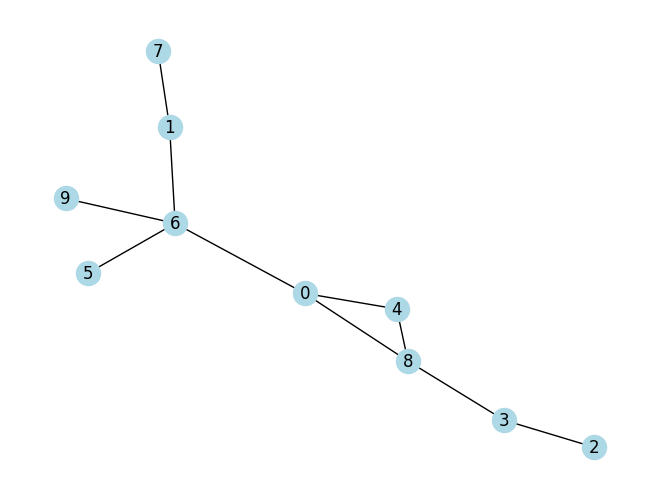

1


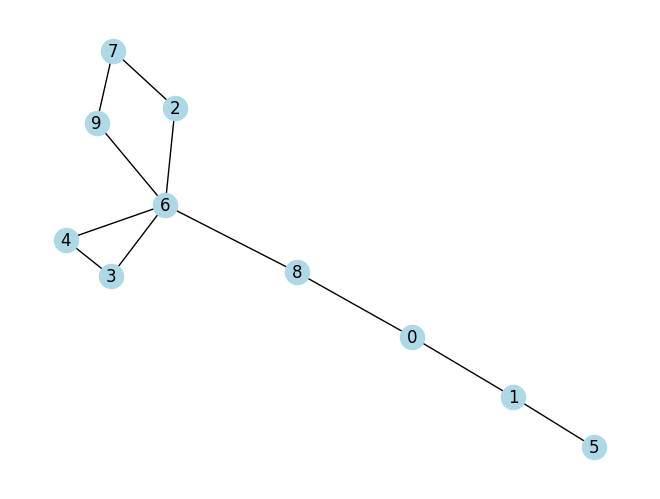

2


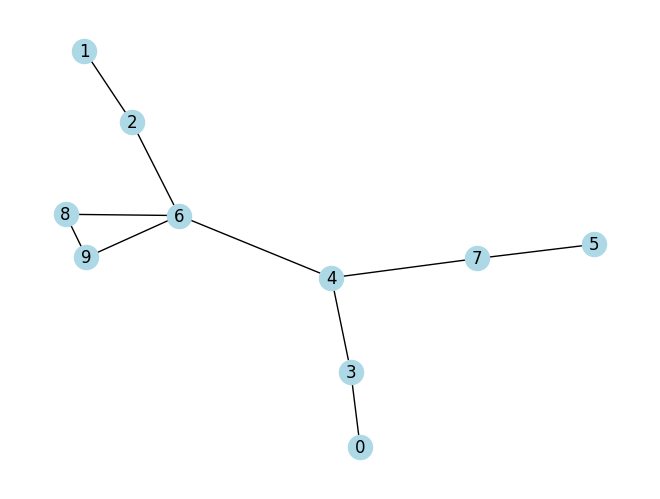

3


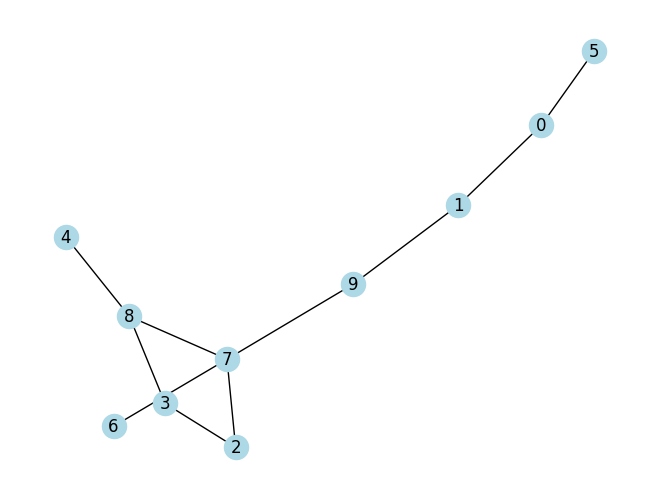

4


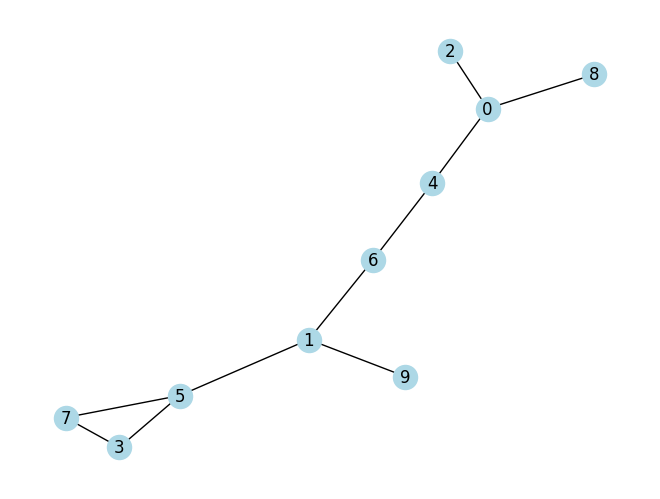

5


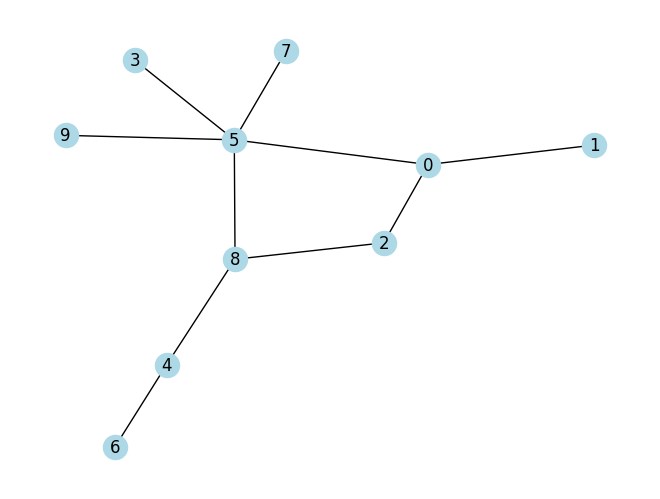

6


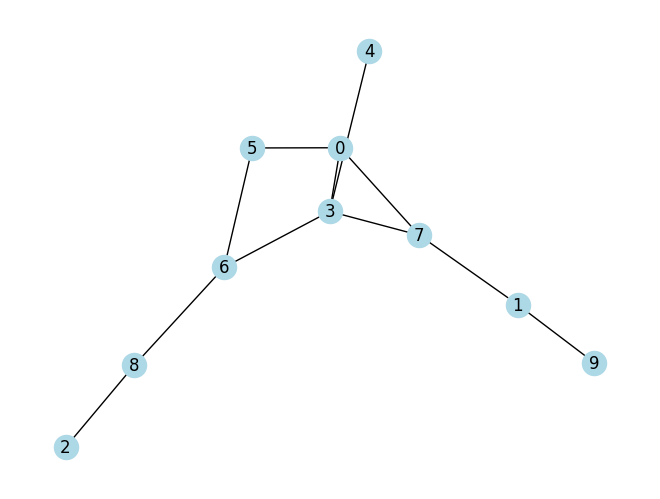

7


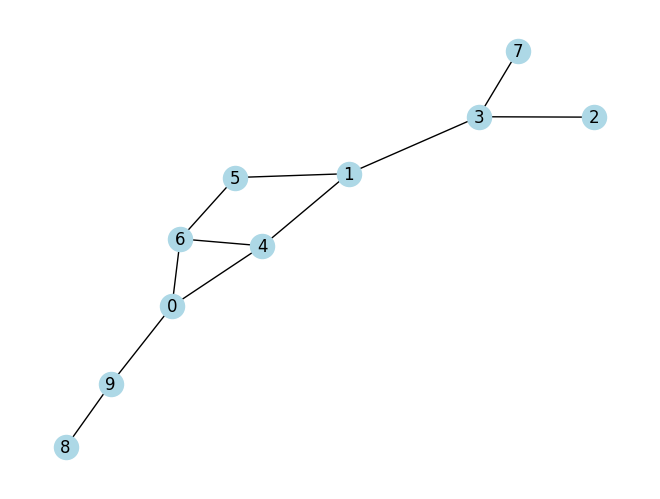

In [3]:
for i in range(len(graphs)):
    print(i)
    nx.draw(graphs[i], with_labels=True, node_color='lightblue', arrows=True)
    plt.show()

In [4]:
for chain_id in range(len(graphs)):
    print(f"\nChain {chain_id}:")
    G = graphs[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")



Chain 0:
Edge 3 -> 8: {'enabling': [[{'automata_id': 7, 'node_id': 9}, {'automata_id': 2, 'node_id': 9}], [{'automata_id': 5, 'node_id': 2}, {'automata_id': 6, 'node_id': 1}, {'automata_id': 7, 'node_id': 4}], [{'automata_id': 4, 'node_id': 5}]]}
Edge 3 -> 2: {}
Edge 8 -> 4: {'enabling': [[{'automata_id': 2, 'node_id': 4}, {'automata_id': 5, 'node_id': 3}, {'automata_id': 1, 'node_id': 4}], [{'automata_id': 1, 'node_id': 3}, {'automata_id': 2, 'node_id': 8}, {'automata_id': 6, 'node_id': 3}], [{'automata_id': 1, 'node_id': 6}]]}
Edge 8 -> 0: {}
Edge 4 -> 0: {}
Edge 0 -> 6: {'enabling': [[{'automata_id': 3, 'node_id': 9}, {'automata_id': 5, 'node_id': 7}, {'automata_id': 1, 'node_id': 4}], [{'automata_id': 6, 'node_id': 3}, {'automata_id': 4, 'node_id': 4}]]}
Edge 6 -> 5: {}
Edge 6 -> 9: {'enabling': [[{'automata_id': 1, 'node_id': 9}, {'automata_id': 6, 'node_id': 1}]]}
Edge 6 -> 1: {}
Edge 1 -> 7: {}

Chain 1:
Edge 6 -> 2: {}
Edge 6 -> 4: {}
Edge 6 -> 3: {'enabling': [[{'automata_id'

In [5]:
vecs = get_vectors(graphs)
print(len(vecs))
print(vecs[0])

Error: Potential combinations (1,000,000) exceed limit (300,000)
Consider reducing number of automata or states per automaton
Current automata states: [10, 10, 10, 10, 10, 10]
Reduced to 900,000 combinations
Reduced to 810,000 combinations
Reduced to 729,000 combinations
Reduced to 656,100 combinations
Reduced to 590,490 combinations
Reduced to 531,441 combinations
Reduced to 472,392 combinations
Reduced to 419,904 combinations
Reduced to 373,248 combinations
Reduced to 331,776 combinations
Reduced to 294,912 combinations
Error: Potential combinations (2,949,120) exceed limit (300,000)
Consider reducing number of automata or states per automaton
Current automata states: [8, 8, 8, 8, 8, 9, 10]
Reduced to 2,654,208 combinations
Reduced to 2,359,296 combinations
Reduced to 2,097,152 combinations
Reduced to 1,835,008 combinations
Reduced to 1,605,632 combinations
Reduced to 1,404,928 combinations
Reduced to 1,229,312 combinations
Reduced to 1,075,648 combinations
Reduced to 941,192 combina

In [6]:
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

250000it [00:00, 3759981.07it/s]


In [7]:
indexes = list(range(len(vecs)))
samples = []

In [8]:
for i in get_sample(vecs[0], graphs):
    print(f"input vec: {i}")
    states, log_cpy = solve(i[0], i[1], list(graphs.values()), len(i[0]))
    pprint(log_cpy)
    break

input vec: ([3, 6, 7, 8, 4, 0, 0, 0], 0)


RecursionError: maximum recursion depth exceeded

In [ ]:
total = 0

error_samples = []
logs = []
for i in tqdm(indexes):
    for sample in get_sample(vecs[i], graphs):
        try:
            total += 1

            in_states = sample[0]
            in_target_nodes = [sample[1]]

            states, target_nodes, sample_log = process_graphs(list(graphs.values()), in_states, in_target_nodes, len(in_states))
                
            if states is not None:
                logs.append({'sample': sample, 'target_nodes': target_nodes, 'log': sample_log})  # Add this ONE sample list to the main list
        except RecursionError as e:
            continue

  0%|          | 0/250000 [00:00<?, ?it/s]

3


  0%|          | 1/250000 [00:01<126:53:54,  1.83s/it]

12


  0%|          | 2/250000 [00:03<123:56:48,  1.78s/it]

...

66


  0%|          | 9/250000 [00:15<115:30:00,  1.66s/it]

84


  0%|          | 12/250000 [00:18<108:30:39,  1.56s/it]

92


In [10]:
print(f"Total: {total}")
print(f"Solved logs length: {len(logs)}")
print(f"Success rate: {round(len(logs)/total, 2)*100}%")
print(f"Unsolved rate: {round((total-len(logs))/total,2)*100}%")

Total: 100
Solved logs length: 8
Success rate: 8.0%
Unsolved rate: 92.0%


In [ ]:
def parse_log(log, sample, target_nodes):
    dic = {}
    init_state = log[1]
    end_idx = init_state.index("]")
    init_state = init_state[2:end_idx+1]
    # Parse the string into a Python list using ast.literal_eval
    parsed_list = ast.literal_eval(init_state)
    # Create a dictionary with indices as keys and list values as values
    init_state_dict = {i: value for i, value in enumerate(parsed_list)}
    # Print the result
    dic['init_state'] = init_state_dict

    # get all indexes of ***
    start_idx = []
    for i in range(len(log)):
        if log[i].startswith("*"*30):
            start_idx.append(i+1)

    target_nodes_lst = []
    for tn in start_idx:
        target_nodes_lst.append(int(log[tn][log[tn].index("TN")+3:]))

    # Parse the string into a Python list using ast.literal_eval
    parsed_list = target_nodes_lst
    # Create a dictionary with indices as keys and list values as values
    parsed_target_states_dict = OrderedDict((i, value) for i, value in enumerate(parsed_list))

    dic['stack'] = parsed_target_states_dict
    
    path = []
    last_num_of_indents = 0
    # deep copy
    curr_states = {k: v for k, v in init_state_dict.items()}

    # path.append(f"START {sample[0]} TARGET {target_nodes}")

    # for item in log:

    #     curr_num_of_indents = item.count("-")

    #     if "PATH" in item:
    #         path.append(f"{item.replace('-', '')}")

    #     # if " U" in item or " D" in item:
    #     #     path.append(item)

    #     if "RS " in item:
    #         tmp = item.replace("-", "")
    #         rs = ast.literal_eval(item.split("RS ")[1])
    #         res_dic = {}
    #         for rule in rs:
    #             res_dic[rule['automata_id']] = rule['node_id']

    #         string = ""
    #         for key, value in res_dic.items():
    #             string += f"{key}: {value}, "
    #         string = string[:-2]
    #         path.append(f"RULESET [{string}]")

    #     if "RULE" in item:
    #         # path.append("TF")
    #         rule = ast.literal_eval(item.split("RULE ")[1])
    #         automata_id = rule['automata_id']
    #         node_id = rule['node_id']
    #         path.append(f"RULE {automata_id}: {node_id}")

    #     if "->" in item:
    #         tmp = item.replace("-", "")
    #         curr_states[int(tmp.split(":")[0])] = int(item.split("-> ")[1])
    #         path.append(f"MOVE {item.replace('--', '')} = {list(curr_states.values())}")

    path.append({"START": sample[0]})
    path.append({"TARGET": target_nodes})
    
    for item in log:

        if "PATH" in item:
            automata_id = int(item.split("PATH ")[1].split(":")[0])
            path.append({"PATH": {automata_id: ast.literal_eval(item.split(": ")[1])}})

        # if " U" in item or " D" in item:
        #     path.append(item)

        if "RS " in item:
            tmp = item.replace("-", "")
            rs = ast.literal_eval(item.split("RS ")[1])
            res_dic = {}
            for rule in rs:
                res_dic[rule['automata_id']] = rule['node_id']

            string = ""
            for key, value in res_dic.items():
                string += f"{key}: {value}, "
            string = string[:-2]
            path.append({"RULESET": res_dic})

        if "RULE" in item:
            # path.append("TF")
            rule = ast.literal_eval(item.split("RULE ")[1])
            automata_id = rule['automata_id']
            node_id = rule['node_id']
            path.append({"RULE": {automata_id: node_id}})

        if "->" in item:
            tmp = item.replace("-", "")
            curr_states[int(tmp.split(":")[0])] = int(item.split("-> ")[1])
            path.append({"MOVE": {int(tmp.split(":")[0]): ({int(item.split(": ")[1].split(" ->")[0]): int(item.split("-> ")[1])}, list(curr_states.values()))}})


    dic['path'] = path

    return dic

In [ ]:
paths = []

for log in tqdm(logs):
    dict_of_path = parse_log(log['log'], sample=log['sample'], target_nodes=log['target_nodes'])
    paths.append(dict_of_path)

len(paths)

100%|██████████| 10/10 [00:00<00:00, 380.57it/s]


10

In [13]:
import pickle
# open parsed_data.pkl
with open('../parsed_data.pkl', 'rb') as f:
    parsed_data = pickle.load(f)
print(f"Parsed data loaded with {len(parsed_data)} entries")
# print first 5 entries
for i in range(5):
    print(parsed_data[i])

Parsed data loaded with 768 entries
{'init_state': {0: 0, 1: 2, 2: 3, 3: 3}, 'stack': OrderedDict([(0, 1), (1, 1), (2, 2), (3, 2)]), 'path': [{'START': [0, 2, 3, 3]}, {'TARGET': [1, 1, 2, 2]}, {'PATH': {0: [0, 1]}}, {'RULESET': {1: 3, 2: 3}}, {'RULE': {1: 3}}, {'PATH': {1: [2, 3]}}, {'MOVE': {1: ({2: 3}, [0, 3, 3, 3])}}, {'RULE': {2: 3}}, {'MOVE': {0: ({0: 1}, [1, 3, 3, 3])}}, {'PATH': {1: [3, 1]}}, {'RULESET': {3: 1, 2: 0}}, {'RULE': {2: 0}}, {'PATH': {2: [3, 0]}}, {'RULESET': {3: 0}}, {'RULE': {3: 0}}, {'PATH': {3: [3, 1, 0]}}, {'MOVE': {3: ({3: 1}, [1, 3, 3, 1])}}, {'PATH': {3: [1, 0]}}, {'MOVE': {3: ({1: 0}, [1, 3, 3, 0])}}, {'MOVE': {2: ({3: 0}, [1, 3, 0, 0])}}, {'RULE': {3: 1}}, {'PATH': {3: [0, 1]}}, {'MOVE': {3: ({0: 1}, [1, 3, 0, 1])}}, {'MOVE': {1: ({3: 1}, [1, 1, 0, 1])}}, {'PATH': {2: [0, 2]}}, {'MOVE': {2: ({0: 2}, [1, 1, 2, 1])}}, {'PATH': {3: [1, 3, 2]}}, {'MOVE': {3: ({1: 3}, [1, 1, 2, 3])}}, {'PATH': {3: [3, 2]}}, {'MOVE': {3: ({3: 2}, [1, 1, 2, 2])}}]}
{'init_state': 

In [ ]:
paths[-1]['path'] # 50 000

[{'START': [8, 2, 0, 0, 1, 4, 6, 7]},
 {'TARGET': [0, 0, 5, 6, 5, 4, 8, 3]},
 {'PATH': {0: [8, 4, 0]}},
 {'MOVE': {0: ({8: 4}, [4, 2, 0, 0, 1, 4, 6, 7])}},
 {'PATH': {0: [4, 0]}},
 {'MOVE': {0: ({4: 0}, [0, 2, 0, 0, 1, 4, 6, 7])}},
 {'PATH': {1: [2, 4, 0]}},
 {'MOVE': {1: ({2: 4}, [0, 4, 0, 0, 1, 4, 6, 7])}},
 {'PATH': {1: [4, 0]}},
 {'RULESET': {2: 1}},
 {'RULE': {2: 1}},
 {'PATH': {2: [0, 2, 3, 1]}},
 {'MOVE': {2: ({0: 2}, [0, 4, 2, 0, 1, 4, 6, 7])}},
 {'PATH': {2: [2, 3, 1]}},
 {'MOVE': {2: ({2: 3}, [0, 4, 3, 0, 1, 4, 6, 7])}},
 {'PATH': {2: [3, 1]}},
 {'MOVE': {2: ({3: 1}, [0, 4, 1, 0, 1, 4, 6, 7])}},
 {'MOVE': {1: ({4: 0}, [0, 0, 1, 0, 1, 4, 6, 7])}},
 {'PATH': {2: [1, 3, 6, 8, 5]}},
 {'MOVE': {2: ({1: 3}, [0, 0, 3, 0, 1, 4, 6, 7])}},
 {'PATH': {2: [3, 6, 8, 5]}},
 {'RULESET': {4: 2, 7: 8}},
 {'RULE': {4: 2}},
 {'PATH': {4: [1, 8, 2]}},
 {'RULESET': {6: 9}},
 {'RULE': {6: 9}},
 {'PATH': {6: [6, 9]}},
 {'MOVE': {6: ({6: 9}, [0, 0, 3, 0, 1, 4, 9, 7])}},
 {'MOVE': {4: ({1: 8}, [0, 0,

In [ ]:
logs[-1]

{'sample': ([8, 2, 0, 0, 1, 4, 6, 7], 0),
 'target_nodes': [0, 0, 5, 6, 5, 4, 8, 3],
 'log': ['******************************',
  'S [8, 2, 0, 0, 1, 4, 6, 7] TN 0',
  'PL [[8, 4, 0]]',
  'PATH 0: [8, 4, 0]',
  'RLS {}',
  'NOR [8, 2, 0, 0, 1, 4, 6, 7] TN 0',
  '0: 8 -> 4',
  'NORCH [4, 2, 0, 0, 1, 4, 6, 7]',
  '--S [4, 2, 0, 0, 1, 4, 6, 7] TN 0',
  '--PL [[4, 0]]',
  '--PATH 0: [4, 0]',
  '--RLS {}',
  '--NOR [4, 2, 0, 0, 1, 4, 6, 7] TN 0',
  '--0: 4 -> 0',
  '--NORCH [0, 2, 0, 0, 1, 4, 6, 7]',
  '----S [0, 2, 0, 0, 1, 4, 6, 7] TN 0',
  '----PL [[0]]',
  '----REND [0, 2, 0, 0, 1, 4, 6, 7]',
  '******************************',
  'S [2, 0, 0, 1, 4, 6, 7] TN 0',
  'PL [[2, 4, 0]]',
  'PATH 1: [2, 4, 0]',
  'RLS {}',
  'NOR [2, 0, 0, 1, 4, 6, 7] TN 0',
  '1: 2 -> 4',
  'NORCH [4, 0, 0, 1, 4, 6, 7]',
  '--S [4, 0, 0, 1, 4, 6, 7] TN 0',
  '--PL [[4, 0]]',
  '--PATH 1: [4, 0]',
  "--RLS {'enabling': [[{'automata_id': 2, 'node_id': 1}], [{'automata_id': 7, 'node_id': 4}, {'automata_id': 6, 'no